# Figure 3 — Validating the learned representation

Linear-probe test of the frozen foundation bottleneck (v10). A probe is trained to predict
each band's per-source log-SNR from the frozen 0.4\"/px features at detected source centers,
under a spatial hold-out. We compare a **linear** probe (ridge) and a **nonlinear** probe
(2-layer MLP): the gap measures how much band information is present but nonlinearly encoded.

Data: `io/_nb13_outputs/cross_instrument_summary_v10.json`. Saves
`paper/figures/fig3_probe.png`.

In [1]:
import json
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def find_repo_root():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / 'data').is_dir() and (c / 'paper').is_dir():
            return c
    raise RuntimeError('repo root not found')

REPO = find_repo_root()
FIGDIR = REPO / 'paper' / 'figures'; FIGDIR.mkdir(exist_ok=True)
d = json.load(open(REPO / 'io' / '_nb13_outputs' / 'cross_instrument_summary_v10.json'))

BANDS = ['rubin_u','rubin_g','rubin_r','rubin_i','rubin_z','rubin_y',
         'euclid_VIS','euclid_Y','euclid_J','euclid_H']
LABELS = ['u','g','r','i','z','y','VIS','Y','J','H']
ridge = np.array([d['diag2b_source_ridge_r2'][b] for b in BANDS])
mlp   = np.array([d['diag2b_source_mlp_r2'][b]   for b in BANDS])
rubin_mean = d['diag2b_mlp_rubin_mean']; euclid_mean = d['diag2b_mlp_euclid_mean']
print('Rubin MLP mean %.3f  ·  Euclid MLP mean %.3f' % (rubin_mean, euclid_mean))
print('per-band MLP R^2:', dict(zip(LABELS, np.round(mlp, 2))))

Rubin MLP mean 0.412  ·  Euclid MLP mean 0.816
per-band MLP R^2: {'u': 0.2, 'g': 0.46, 'r': 0.42, 'i': 0.51, 'z': 0.49, 'y': 0.39, 'VIS': 0.68, 'Y': 0.83, 'J': 0.89, 'H': 0.87}


saved /home/shemmati/Work/Projects/JAISP/paper/figures/fig3_probe.png


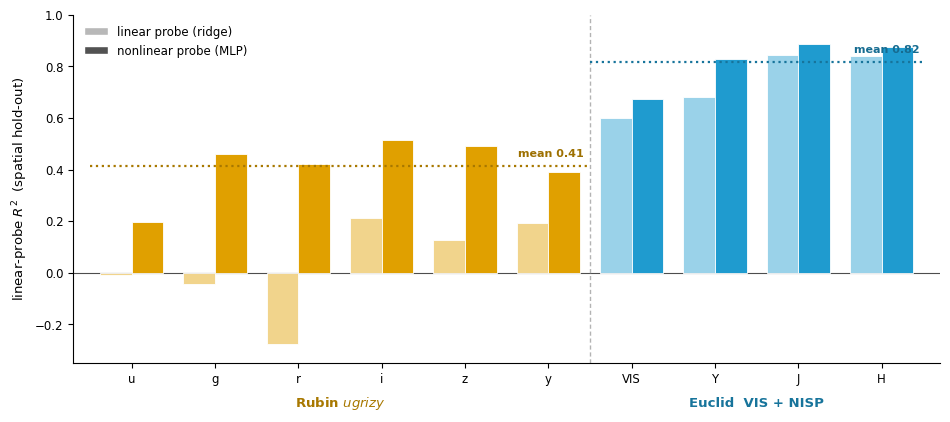

In [2]:
C_RUBIN = '#e0a000'; C_EUCLID = '#1f9bcf'; INK = '#1c2733'; SUB = '#5a6b7e'
def shade(c, f):
    r, g, b = mcolors.to_rgb(c)
    return (r+(1-r)*f, g+(1-g)*f, b+(1-b)*f) if f >= 0 else (r*(1+f), g*(1+f), b*(1+f))

x = np.arange(10); w = 0.38
base = [C_RUBIN]*6 + [C_EUCLID]*4

fig, ax = plt.subplots(figsize=(9.6, 4.3))
ax.axhline(0, color='0.3', lw=0.8, zorder=1)
ax.bar(x - w/2, ridge, w, color=[shade(c, 0.55) for c in base], edgecolor='white', lw=0.6, zorder=3)
ax.bar(x + w/2, mlp,   w, color=base,                          edgecolor='white', lw=0.6, zorder=3)

# instrument divider
ax.axvline(5.5, color='0.7', lw=1.0, ls=(0, (3, 2)), zorder=2)

# mean (nonlinear) lines per instrument
ax.plot([-0.5, 5.5], [rubin_mean]*2, color=shade(C_RUBIN, -0.25), lw=1.6, ls=':', zorder=4)
ax.plot([5.5, 9.5], [euclid_mean]*2, color=shade(C_EUCLID, -0.25), lw=1.6, ls=':', zorder=4)
ax.text(5.42, rubin_mean + 0.03, 'mean %.2f' % rubin_mean, ha='right', va='bottom',
        fontsize=8, color=shade(C_RUBIN, -0.3), weight='bold')
ax.text(9.45, euclid_mean + 0.03, 'mean %.2f' % euclid_mean, ha='right', va='bottom',
        fontsize=8, color=shade(C_EUCLID, -0.3), weight='bold')

ax.set_xticks(x); ax.set_xticklabels(LABELS, fontsize=9)
ax.set_ylabel('linear-probe $R^2$  (spatial hold-out)', fontsize=9.5)
ax.set_ylim(-0.35, 1.0)
ax.set_xlim(-0.7, 9.7)
ax.tick_params(labelsize=8.5)
for s in ('top', 'right'): ax.spines[s].set_visible(False)

# instrument group labels
ax.text(2.5, -0.52, 'Rubin $ugrizy$', ha='center', fontsize=9.5, color=shade(C_RUBIN, -0.25), weight='bold')
ax.text(7.5, -0.52, 'Euclid  VIS + NISP', ha='center', fontsize=9.5, color=shade(C_EUCLID, -0.25), weight='bold')

# legend: light = linear, dark = nonlinear
from matplotlib.patches import Patch
leg = [Patch(fc='0.72', ec='white', label='linear probe (ridge)'),
       Patch(fc='0.32', ec='white', label='nonlinear probe (MLP)')]
ax.legend(handles=leg, loc='upper left', fontsize=8.5, frameon=False)

fig.tight_layout()
out = FIGDIR / 'fig3_probe.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
print('saved', out)
plt.show()